# Model Prediction Comparison on Less Difficult Images

In this notebook, we take one of the images from the `resized ` directory and run it through our three trained models to compare their internal process, code, and predictions:
1. **Custom CNN** (trained from scratch)
2. **MobileNetV2** (transfer learning)
3. **ResNet50** (transfer learning)

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from keras.api.models import load_model
from keras.api.utils import img_to_array

print(f"TensorFlow Version: {tf.__version__}")

2026-03-05 17:06:42.066085: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow Version: 2.18.1


## 1. Constants and Paths
We define the class names for CIFAR-10, the path to our less difficult image, and the paths to our saved models.

In [3]:
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Paths (relative to the notebook's location)
PROJECT_ROOT = '../../'
IMAGE_PATH = os.path.join(PROJECT_ROOT, 'test_images', 'resized ', 'horse.png')

MODEL_CNN_PATH = os.path.join(PROJECT_ROOT, 'models', 'custom_cnn.keras')
MODEL_MOBILENET_PATH = os.path.join(PROJECT_ROOT, 'models', 'mobilenetv2_tl.keras')
MODEL_RESNET_PATH = os.path.join(PROJECT_ROOT, 'models', 'resnet50_tl.keras')

## 2. Load the Models
Let's load all three models into memory.

In [4]:
print("Loading Custom CNN...")
cnn_model = load_model(MODEL_CNN_PATH)

print("Loading MobileNetV2...")
mobilenet_model = load_model(MODEL_MOBILENET_PATH)

print("Loading ResNet50...")
resnet_model = load_model(MODEL_RESNET_PATH)

print("All models loaded successfully!")

Loading Custom CNN...
Loading MobileNetV2...
Loading ResNet50...
All models loaded successfully!


## 3. Visualize the Less Difficult Image
We will load and display the image we are testing.

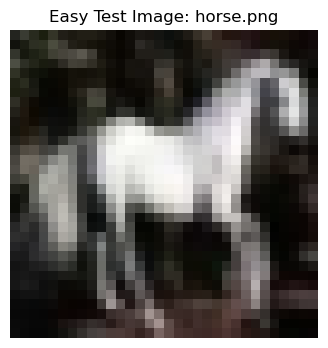

In [5]:
img = Image.open(IMAGE_PATH).convert('RGB')

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis('off')
plt.title("Easy Test Image: horse.png")
plt.show()

## 4. Helper Methods for Preprocessing and Prediction
The CNN model expects `32x32` pixel inputs, while the transfer learning models (MobileNetV2 and ResNet50) expect `96x96` or larger. We need to resize appropriately and scale the pixel values.

In [6]:
def preprocess_image(pil_img, target_size):
    """
    Resizes the image and normalizes it.
    """
    # Resize to the model's expected shape
    img_resized = pil_img.resize(target_size)
    
    # Convert to array and normalize to [0, 1]
    img_array = img_to_array(img_resized) / 255.0
    
    # Add batch dimension: (1, height, width, 3)
    img_batch = np.expand_dims(img_array, axis=0)
    return img_batch

def predict_and_display(model, img_batch, title="Model Predictions"):
    """
    Runs the prediction, plots the top probabilities, and prints the result.
    """
    predictions = model.predict(img_batch, verbose=0)[0]
    
    # Get top 3 predictions
    top_3_indices = predictions.argsort()[-3:][::-1]
    
    print(f"\n--- {title} ---")
    for idx in top_3_indices:
        print(f"{CLASS_NAMES[idx]}: {predictions[idx]*100:.2f}%")
        
    # Plot horizontal bar chart
    classes = [CLASS_NAMES[idx] for idx in top_3_indices]
    probs = [predictions[idx] * 100 for idx in top_3_indices]
    
    plt.figure(figsize=(6, 2))
    plt.barh(classes[::-1], probs[::-1], color='skyblue')
    plt.xlabel('Probability (%)')
    plt.title(title)
    plt.xlim(0, 100)
    plt.tight_layout()
    plt.show()

## 5. Model 1: Custom CNN
Let's see how our baseline custom CNN performs.


--- Custom CNN Predictions ---
horse: 99.95%
dog: 0.03%
cat: 0.01%


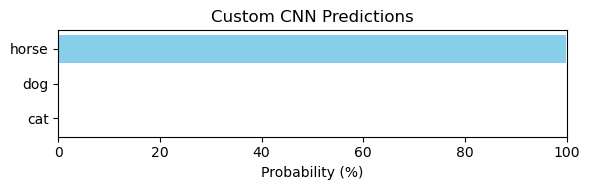

In [7]:
# Preprocess for CNN (32x32)
img_batch_cnn = preprocess_image(img, target_size=(32, 32))

predict_and_display(cnn_model, img_batch_cnn, title="Custom CNN Predictions")

## 6. Model 2: MobileNetV2 (Transfer Learning)
Now we use MobileNetV2, which typically offers better feature extraction.

I0000 00:00:1772726822.289139  389891 service.cc:148] XLA service 0x7fd42237efc0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772726822.290823  389891 service.cc:156]   StreamExecutor device (0): Host, Default Version
2026-03-05 17:07:02.293944: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-05 17:07:02.430800: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.



--- MobileNetV2 Predictions ---
horse: 98.43%
dog: 1.06%
cat: 0.51%


I0000 00:00:1772726824.171325  389891 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


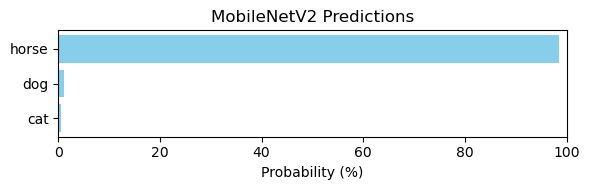

In [8]:
# Preprocess for MobileNetV2 (96x96 according to our app configuration)
img_batch_mobilenet = preprocess_image(img, target_size=(96, 96))

predict_and_display(mobilenet_model, img_batch_mobilenet, title="MobileNetV2 Predictions")

## 7. Model 3: ResNet50 (Transfer Learning)
Finally, let's explore ResNet50's prediction on the exact same image.


--- ResNet50 Predictions ---
bird: 53.79%
cat: 33.97%
airplane: 4.24%


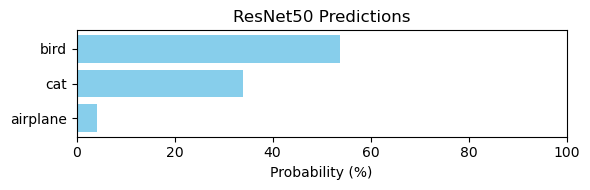

In [9]:
# Preprocess for ResNet50 (using 96x96 as standard transfer learning resolution for our CIFAR setup)
img_batch_resnet = preprocess_image(img, target_size=(96, 96))

predict_and_display(resnet_model, img_batch_resnet, title="ResNet50 Predictions")